In [1]:
from Bio import SeqIO
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# FASTA_PATH = '../data/gfp_aa_seqs.fa'

# gfp_fasta = list(SeqIO.parse(FASTA_PATH, 'fasta'))
# gfp_fastadict = {record.id: record for record in gfp_fasta}

# MUTATIONS_PATH = '../data/mutations.tsv'

# mutations_df = pd.read_csv(MUTATIONS_PATH, delimiter='\t')

# mutations_df['Brightness'] = mutations_df['Brightness'].str.replace(",", '.').astype('float')


# for i, row in mutations_df.iterrows():
#     mutations, gfp_type, brightness = row['aaMutations'].split(':'), row['GFP type'], row['Brightness']
#     ref_seq = list(gfp_fastadict[gfp_type].seq)
#     if mutations != ['WT']:
#         for cur_mut in mutations:
#             ref_aa, ind, new_aa = cur_mut[0], int(cur_mut[1:-1]), cur_mut[-1]
#             if ref_aa == '*':
#                 assert len(ref_seq) == ind
#                 ref_seq.append(new_aa)
#             else:
#                 assert ref_seq[ind] == ref_aa
#                 ref_seq[ind] = new_aa
#     new_seq = ''.join(ref_seq)
#     mutations_df.loc[i, 'seq'] = new_seq
        
    

In [3]:
mutations_df = pd.read_csv("../data/data.csv")
mutations_df.Brightness = mutations_df.Brightness.astype('float32')

In [4]:
# Находим яркость WT для каждого типа
wt_brightness = mutations_df[mutations_df['aaMutations'] == 'WT'].set_index('GFP type')['Brightness']

# Применяем вычитание для всех строк
mutations_df['rel_brightness'] = mutations_df.apply(
    lambda row: row['Brightness'] - wt_brightness[row['GFP type']], 
    axis=1
)

In [5]:
mutations_df

,Unnamed: 0,aaMutations,GFP type,Brightness,seq,rel_brightness
0,0,WT,avGFP,3.719212,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.000000
1,1,A109D,avGFP,1.301030,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,-2.418182
2,2,A109D:N145D:I187V:M232T:L235P,avGFP,1.301031,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,-2.418181
3,3,A109D:Y142N:H147L:E221G,avGFP,1.301189,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,-2.418023
4,4,A109G,avGFP,3.708478,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,-0.010734
...,...,...,...,...,...,...
141567,141567,T128A:V150A:S158P,ppluGFP,4.035788,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,-0.190036
141568,141568,E122K:S171P:V196A,ppluGFP,4.096312,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,-0.129512
141569,141569,G22D,ppluGFP,4.068633,MPAMKIECRITGTLNGVEFELVDGGEGTPEQGRMTNKMKSTKGALT...,-0.157191
141570,141570,G107C:S171T:T203A,ppluGFP,3.939097,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,-0.286727


<Axes: >

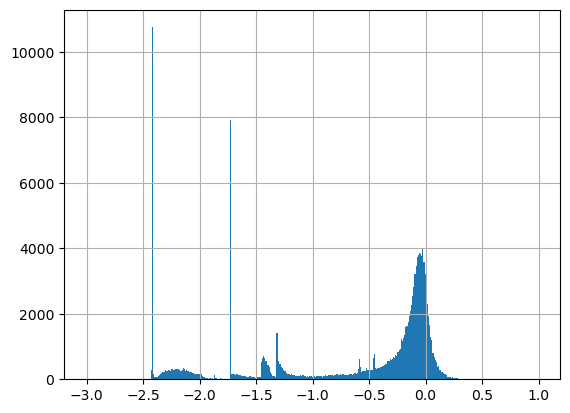

In [6]:
mutations_df['rel_brightness'].hist(bins=np.arange(-3, 1, 0.01))

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Делим яркость на 4 группы (квартили) или 5 групп (квинтили)
# Это гарантирует, что в каждой группе будет достаточно образцов
mutations_df['brightness_group'] = pd.qcut(
    mutations_df['rel_brightness'], 
    q=4,  # 4 группы: очень тусклые, тусклые, яркие, очень яркие
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    duplicates='drop'  # если много одинаковых значений
)

# 2. Первый сплит (train+val vs test) со стратификацией
X_temp, X_test, y_temp, y_test = train_test_split(
    mutations_df['seq'],
    mutations_df['rel_brightness'],
    test_size=0.15,
    stratify=mutations_df['brightness_group'],  # <-- СТРАТИФИКАЦИЯ!
    random_state=42
)

# 3. Второй сплит (train vs val) - тоже со стратификацией
# Нужно создать группы для временной выборки
temp_groups = mutations_df.loc[X_temp.index, 'brightness_group']

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,  
    stratify=temp_groups,  
    random_state=42
)

/tmp/d_ryabov.5169/ipykernel_745806/2631001423.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutations_df['brightness_group'] = pd.qcut(


<Axes: >

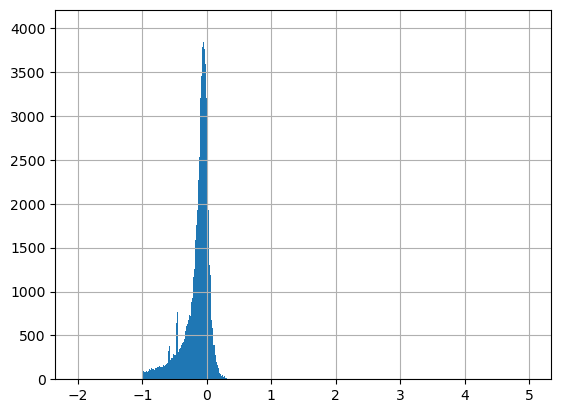

In [10]:
mutations_df.query("rel_brightness >= -1").rel_brightness.hist(bins=np.arange(-2, 5, 0.01))

In [11]:
mutations_df = mutations_df.query("rel_brightness >= -1")

In [16]:
pd.concat([X_train, y_train], axis=1).to_csv('../data/rel_brightness_top/train.csv')
pd.concat([X_val, y_val], axis=1).to_csv('../data/rel_brightness_top/val.csv')
pd.concat([X_test, y_test], axis=1).to_csv('../data/rel_brightness_top/test.csv')

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from functools import partial




class SimpleDataset(Dataset):    
    def __init__(self, items, targets):
        self.seqs = items
        self.targets = torch.tensor(targets, dtype=torch.float32)
    
    def __len__(self):
        return len(self.seqs)
    
    def __getitem__(self, idx):
        return self.seqs[idx], self.targets[idx]


def collate_fn(batch, tokenizer, max_length=1024):
    """
    Токенизация всего батча целиком (на CPU, как и должно быть)
    """
    sequences = [item[0] for item in batch]
    targets = torch.stack([item[1] for item in batch])
    
    inputs = tokenizer(
        sequences,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    
    return inputs, targets 

In [8]:
from transformers import AutoTokenizer, AutoModel
import torch

# Выберите размер модели:
# - "facebook/esm2_t6_8M_UR50D"   (8M параметров, самый лёгкий)
# - "facebook/esm2_t12_35M_UR50D" (35M)
# - "facebook/esm2_t30_150M_UR50D" (150M)
# - "facebook/esm2_t33_650M_UR50D" (650M, хороший баланс)
# - "facebook/esm2_t36_3B_UR50D"   (3B, самый тяжёлый)


/trinity/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import torch.nn as nn
import torch.nn.init as init


class ResidualBlock1D(nn.Module):
    """
    Остаточный блок с:
    - Pre-activation (Order: Norm -> ReLU -> Linear) для лучшей сходимости
    - LayerNorm вместо BatchNorm (лучше для векторов фиксированной длины)
    - Dropout для регуляризации
    """
    def __init__(self, input_dim: int, output_dim: int, dropout_rate: float = 0.2):
        super().__init__()        
        self.skipconnection = nn.Linear(input_dim, output_dim)
        
        self.norm1 = nn.LayerNorm(input_dim)
        self.linear1 = nn.Linear(input_dim, input_dim)
        self.norm2 = nn.LayerNorm(output_dim)
        self.linear2 = nn.Linear(input_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()
        
        # Инициализация весов (Xavier для лучшей сходимости)
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in [self.linear1, self.linear2]:
            init.xavier_uniform_(m.weight)
            if m.bias is not None:
                init.constant_(m.bias, 0)
    
    def forward(self, x):
        skipconnetion = self.skipconnection(x)
        out = self.linear1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.linear2(out)
        out = self.norm2(out)
        out = self.relu(out)
        out = out + skipconnetion
        out = self.relu(out)
        return out

In [10]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from typing import Optional, Tuple, List
import warnings
warnings.filterwarnings("ignore", message="Some weights of EsmModel were not initialized")

class ESM2Block(nn.Module):
    
    def __init__(self,
                 model_name: str = "facebook/esm2_t33_650M_UR50D",
                 freeze: bool = True,
                 max_length: int = 1024,
                 device: str = None):
        """
        Args:
            model_name: имя модели ESM-2 на Hugging Face
            freeze: заморозить веса ESM-2
            pooling_strategy: стратегия пулинга ('mean', 'max', 'cls')
            max_length: максималtruncation=True,
            padding=True, ьная длина последовательности
            device: устройство ('cuda' или 'cpu')
        """
        super().__init__()
        self.device = device
        
        # Устройство
        self.max_length = max_length
        
        # Загрузка токенизатора и модели
        self.esm = AutoModel.from_pretrained(model_name).to(self.device)
        
        # Заморозка весов
        if freeze:
            print("Режим: ESM-2 заморожен")
            for param in self.esm.parameters():
                param.requires_grad = False
        else:
            print("Режим: ESM-2 дообучается")
            # Можно разморозить только последние слои
            self._unfreeze_last_layers(num_layers=6)
        
        # Перенос на устройство
        self.esm.eval() if freeze else self.esm.train()
    
    def _unfreeze_last_layers(self, num_layers: int = 6):
        """Размораживает последние слои ESM-2"""
        # Замораживаем всё
        for param in self.esm.parameters():
            param.requires_grad = False
        
        # Размораживаем последние num_layers слоёв
        total_layers = len(self.esm.encoder.layer)
        for layer in self.esm.encoder.layer[total_layers - num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
        
        # Размораживаем embedding слой
        for param in self.esm.embeddings.parameters():
            param.requires_grad = True
    
    def forward(self, inputs) -> torch.Tensor:
        input_ids = inputs['input_ids'].to(self.device)
        attention_mask = inputs['attention_mask'].to(self.device)
        outputs = self.esm(input_ids, attention_mask)
        embeddings = outputs.pooler_output
        return embeddings
    

In [11]:
class GFPRegressionModel(nn.Module):
    def __init__(self,
                 residual_dim: list,
                 esm_model_name: str = "facebook/esm2_t33_650M_UR50D",
                 freeze_esm: bool = True,
                 dropout_rate: float = 0.2,
                 max_length: int = 1024,
                 device: str = None):
        super().__init__()
        
        self.esm_block = ESM2Block(esm_model_name, freeze_esm, max_length, device)
        self.regressor = nn.Sequential(*[ResidualBlock1D(residual_dim[i], residual_dim[i + 1]) for i in range(len(residual_dim) - 1)]).to(device)

    def forward(self, x):
        x = self.esm_block(x)
        x = self.regressor(x)
        return x

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================
# 1. ФУНКЦИЯ ДЛЯ ОДНОЙ ЭПОХИ ОБУЧЕНИЯ
# ============================================

def train_epoch(model, dataloader, optimizer, criterion, device, accumulation_steps=1):
    """
    Одна эпоха обучения
    
    Args:
        model: модель
        dataloader: DataLoader с данными (должен выдавать sequences и targets)
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство ('cuda' или 'cpu')
        accumulation_steps: шаги накопления градиентов (для больших батчей)
    
    Returns:
        avg_loss: средняя потеря за эпоху
        predictions: список предсказаний
        targets: список истинных значений
    """
    model.train()
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    # Для накопления градиентов
    optimizer.zero_grad()
    
    # Прогресс-бар
    pbar = tqdm(dataloader, desc="Training")
    
    for batch_idx, (sequences, targets) in enumerate(pbar):
        # Переносим targets на устройство
        targets = targets.to(device)
        
        # Forward pass
        predictions = model(sequences)
        
        # Loss
        loss = criterion(predictions, targets)
        
        # Backward pass с накоплением градиентов
        loss = loss / accumulation_steps
        loss.backward()
        
        # Обновляем веса после accumulation_steps шагов
        if (batch_idx + 1) % accumulation_steps == 0:
            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        # Статистика
        total_loss += loss.item() * accumulation_steps
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        
        # Обновляем прогресс-бар
        pbar.set_postfix({'loss': loss.item() * accumulation_steps})
    
    # Обработка остаточных градиентов
    if (batch_idx + 1) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()
    
    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, np.array(all_predictions), np.array(all_targets)


# ============================================
# 2. ФУНКЦИЯ ДЛЯ ВАЛИДАЦИИ
# ============================================

def validate_epoch(model, dataloader, criterion, device):
    """
    Одна эпоха валидации
    
    Args:
        model: модель
        dataloader: DataLoader с данными
        criterion: функция потерь
        device: устройство
    
    Returns:
        avg_loss: средняя потеря
        predictions: список предсказаний
        targets: список истинных значений
        metrics: словарь с метриками (R², RMSE, MAE)
    """
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for sequences, targets in pbar:
            targets = targets.to(device)
            
            predictions = model(sequences)
            loss = criterion(predictions, targets)
            
            total_loss += loss.item()
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    
    # Вычисляем метрики
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    
    metrics = {
        'r2': r2_score(all_targets, all_predictions),
        'rmse': np.sqrt(mean_squared_error(all_targets, all_predictions)),
        'mae': mean_absolute_error(all_targets, all_predictions),
        'correlation': np.corrcoef(all_targets, all_predictions)[0, 1]
    }
    
    return avg_loss, all_predictions, all_targets, metrics


# ============================================
# 3. ОСНОВНАЯ ФУНКЦИЯ ТРЕНИРОВКИ
# ============================================

def train_model(model,
                train_loader,
                val_loader,
                epochs=50,
                lr=1e-3,
                weight_decay=1e-4,
                device='cuda',
                patience=15,
                scheduler_patience=10,
                scheduler_factor=0.5,
                accumulation_steps=1,
                save_best=True,
                save_path='best_model.pt',
                verbose=True):
    """
    Полный цикл обучения модели
    
    Args:
        model: модель для обучения
        train_loader: DataLoader для обучения
        val_loader: DataLoader для валидации
        epochs: количество эпох
        lr: learning rate
        weight_decay: L2 регуляризация
        device: устройство
        patience: ранняя остановка (сколько эпох без улучшения)
        scheduler_patience: patience для ReduceLROnPlateau
        scheduler_factor: множитель уменьшения LR
        accumulation_steps: накопление градиентов
        save_best: сохранять лучшую модель
        save_path: путь для сохранения
        verbose: печатать детали
    
    Returns:
        history: словарь с историей обучения
        best_model: лучшая модель (если save_best=True)
    """
    
    # Перемещаем модель на устройство
    
    # Оптимизатор
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    
    # Scheduler для уменьшения LR при застревании
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        verbose=verbose
    )
    
    # Функция потерь
    criterion = nn.MSELoss()
    
    # История обучения
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_r2': [],
        'val_rmse': [],
        'val_mae': [],
        'val_corr': [],
        'lr': []
    }
    
    # Для ранней остановки
    best_val_loss = float('inf')
    best_val_r2 = -float('inf')
    patience_counter = 0
    
    print(f"\n{'='*60}")
    print(f"НАЧАЛО ОБУЧЕНИЯ")
    print(f"{'='*60}")
    print(f"Устройство: {device}")
    print(f"Эпох: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"Weight decay: {weight_decay}")
    print(f"Patience: {patience}")
    print(f"{'='*60}\n")
    
    for epoch in range(epochs):
        # Обучение
        train_loss, train_preds, train_targets = train_epoch(
            model, train_loader, optimizer, criterion, device, accumulation_steps
        )
        
        # Валидация
        val_loss, val_preds, val_targets, val_metrics = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Обновляем scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_r2'].append(val_metrics['r2'])
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_mae'].append(val_metrics['mae'])
        history['val_corr'].append(val_metrics['correlation'])
        history['lr'].append(current_lr)
        
        # Печать результатов
        if verbose:
            print(f"\n{'='*50}")
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"{'='*50}")
            print(f"Train Loss: {train_loss:.4f}")
            print(f"Val Loss:   {val_loss:.4f}")
            print(f"Val R²:     {val_metrics['r2']:.4f}")
            print(f"Val RMSE:   {val_metrics['rmse']:.4f}")
            print(f"Val MAE:    {val_metrics['mae']:.4f}")
            print(f"Val Corr:   {val_metrics['correlation']:.4f}")
            print(f"LR:         {current_lr:.2e}")
            
            # Небольшой анализ
            if val_metrics['r2'] < 0:
                print(f"⚠️  Внимание: R² отрицательный! Модель хуже среднего")
        
        # Сохранение лучшей модели
        if save_best and val_metrics['r2'] > best_val_r2:
            best_val_r2 = val_metrics['r2']
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_r2': val_metrics['r2'],
                'history': history
            }, save_path)
            if verbose:
                print(f"✅ Сохранена лучшая модель (R² = {val_metrics['r2']:.4f})")
        else:
            patience_counter += 1
        
        # Ранняя остановка
        if patience_counter >= patience:
            if verbose:
                print(f"\n🛑 Early stopping! Нет улучшения {patience} эпох.")
            break
    
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print(f"{'='*60}")
    print(f"Лучший Val R²: {best_val_r2:.4f}")
    print(f"Лучший Val Loss: {best_val_loss:.4f}")
    print(f"{'='*60}")
    
    # Загружаем лучшую модель
    if save_best:
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Загружена лучшая модель из {save_path}")
    
    return history, model


# ============================================
# 4. ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ
# ============================================

def test_model(model, test_loader, device, load_path=None):
    """
    Тестирование модели на отложенной выборке
    
    Args:
        model: модель
        test_loader: DataLoader для теста
        device: устройство
        load_path: путь к сохранённой модели (опционально)
    
    Returns:
        predictions, targets, metrics
    """
    
    if load_path:
        checkpoint = torch.load(load_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Загружена модель из {load_path}")
    
    model.eval()
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Testing")
        for sequences, targets in pbar:
            targets = targets.to(device)
            predictions = model(sequences)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    
    metrics = {
        'r2': r2_score(all_targets, all_predictions),
        'rmse': np.sqrt(mean_squared_error(all_targets, all_predictions)),
        'mae': mean_absolute_error(all_targets, all_predictions),
        'correlation': np.corrcoef(all_targets, all_predictions)[0, 1]
    }
    
    print(f"\n{'='*50}")
    print(f"ТЕСТОВЫЕ РЕЗУЛЬТАТЫ")
    print(f"{'='*50}")
    print(f"R²:     {metrics['r2']:.4f}")
    print(f"RMSE:   {metrics['rmse']:.4f}")
    print(f"MAE:    {metrics['mae']:.4f}")
    print(f"Corr:   {metrics['correlation']:.4f}")
    print(f"{'='*50}")
    
    return all_predictions, all_targets, metrics



In [13]:
model = GFPRegressionModel([1280, 800, 400, 100, 64, 1], device='cpu')

BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
my_collate_fn = partial(collate_fn, tokenizer=tokenizer, max_length=1024)    

train_dataset = SimpleDataset(X_train.to_numpy(), y_train.to_numpy())
val_dataset = SimpleDataset(X_val.to_numpy(), y_val.to_numpy())
test_dataset = SimpleDataset(X_test.to_numpy(), y_test.to_numpy())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=my_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=my_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=my_collate_fn)


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Режим: ESM-2 заморожен


In [14]:
isinstance(nn.DataParallel(model), torch.nn.parallel.DataParallel)

True

In [15]:
isinstance(model, torch.nn.parallel.DataParallel)

False

In [16]:
 # history, best_model = train_model(
 #        model=model,
 #        train_loader=train_loader,
 #        val_loader=val_loader,
 #        epochs=50,
 #        lr=1e-3,
 #        device='cuda',
 #        patience=15,
 #        save_path='../data/best_models/best_gfp_model.pt'
 #    )

In [17]:
import sys
sys.path.append('../src/FluoreModel/')

import torch

import model
from torch import nn

In [18]:
gfp_model = nn.DataParallel(model.GFPRegressionModel([1280, 1000, 700, 500, 300, 100, 75, 50, 25], device='cpu', freeze_esm=True))

checkpoint = torch.load('../data/best_models/gfp2_best.pt', 'cpu', weights_only=False)
gfp_model.load_state_dict(checkpoint['model_state_dict'])

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Режим: ESM-2 заморожен


RuntimeError: Error(s) in loading state_dict for DataParallel:
	Missing key(s) in state_dict: "module.final_linear.weight", "module.final_linear.bias", "module.norm.weight", "module.norm.bias". 
	Unexpected key(s) in state_dict: "module.regressor.8.skipconnection.weight", "module.regressor.8.skipconnection.bias", "module.regressor.8.norm1.weight", "module.regressor.8.norm1.bias", "module.regressor.8.linear1.weight", "module.regressor.8.linear1.bias", "module.regressor.8.norm2.weight", "module.regressor.8.norm2.bias", "module.regressor.8.linear2.weight", "module.regressor.8.linear2.bias", "module.regressor.9.skipconnection.weight", "module.regressor.9.skipconnection.bias", "module.regressor.9.norm1.weight", "module.regressor.9.norm1.bias", "module.regressor.9.linear1.weight", "module.regressor.9.linear1.bias", "module.regressor.9.norm2.weight", "module.regressor.9.norm2.bias", "module.regressor.9.linear2.weight", "module.regressor.9.linear2.bias", "module.regressor.10.skipconnection.wei

In [ ]:
gfp_model.load_state_dict(checkpoint['model_state_dict'])